# Week 5: Scenario Analysis & Policy Intervention Simulation

### Learning Objective
Build a what-if scenario module to simulate the long-term emissions impact of policy interventions across the 10 focus countries, developing practical skills in parameterized analysis and comparative visualization.

### Countries of Focus
The analysis evaluates the designated mix of global emitters: 
*China, USA, India, Russia, Japan, Germany, Brazil, United Kingdom, South Africa, and Australia.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Set visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 1. Load the comprehensive OWID CO2 dataset
data_url = "https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.csv"
df = pd.read_csv(data_url)

# 2. Scope definition based on Project Requirements
focus_countries = [
    "China", "United States", "India", "Russia", "Japan", 
    "Germany", "Brazil", "United Kingdom", "South Africa", "Australia"
]

# 3. Pre-process to extract historical metrics (1990-2024)
df_hist = df[(df["year"] >= 1990) & (df["year"] <= 2024) & (df["country"].isin(focus_countries))].copy()
print(f"Loaded {df_hist.shape[0]} historical records for the 10 focus countries.")

Loaded 340 historical records for the 10 focus countries.


### 5.1 Scenario Design Framework

To evaluate potential pathways for future emissions mitigation, we define three standard test cases spanning a 15-year forecast horizon (**2025 to 2040**):

| Scenario | Label | Operational Logic |
| :--- | :--- | :--- |
| **Scenario A** | **Business as Usual (BAU)** | No policy interventions. Extrapolates emissions forward using the optimized `ETS(A,Ad,N)` (Holt's Damped Trend) model from Week 4. |
| **Scenario B** | **Moderate Mitigation** | Introduces an active policy framework causing a compounding linear reduction rate of **2% per year** relative to the BAU baseline, starting in 2025. |
| **Scenario C** | **Aggressive Mitigation** | Introduces intense policy frameworks causing an active compounding linear reduction rate of **5% per year** relative to the BAU baseline, starting in 2025. |

#### Analytical Basis & Limitations
> **Note on Methodology:** These scenarios serve as stylized, parameterized projections rather than scientifically calibrated climate models. They do not account for macro-economic feedback loops, technological break-points, or specific sector limits. They provide baseline boundaries to assess target compliance.

In [2]:
# 5.2 Scenario Calculation
projected_records = []

for country in focus_countries:
    # Isolate country-specific historical timeline up to 2024
    country_data = df_hist[df_hist["country"] == country].sort_values("year")
    
    # Train Week 4 Baseline ETS(A,Ad,N) Model using historical actuals
    # Note: If 2024 numbers have missing values, fill using forward-fill
    ts_series = country_data.set_index("year")["co2"].ffill()
    
    # Fit the Damped Trend Model
    model = ExponentialSmoothing(ts_series, trend="add", damped_trend=True, seasonal=None)
    fit = model.fit(optimized=True)
    
    # Generate the out-of-sample BAU Baseline forecast up to 2040
    years_forecast = list(range(2025, 2041))
    bau_forecast = fit.forecast(len(years_forecast))
    
    # Calculate scenarios over the 2025-2040 horizon
    for idx, year in enumerate(years_forecast):
        bau_val = max(0.0, bau_forecast.iloc[idx]) # Prevent negative emissions math
        t = year - 2024 # Years since implementation
        
        # Scenario A: Business As Usual
        projected_records.append({"country": country, "year": year, "scenario": "BAU", "co2_projected": bau_val})
        
        # Scenario B: Moderate Mitigation (-2% annually relative to BAU)
        mod_val = max(0.0, bau_val * (1 - 0.02 * t))
        projected_records.append({"country": country, "year": year, "scenario": "Moderate Mitigation", "co2_projected": mod_val})
        
        # Scenario C: Aggressive Mitigation (-5% annually relative to BAU)
        agg_val = max(0.0, bau_val * (1 - 0.05 * t))
        projected_records.append({"country": country, "year": year, "scenario": "Aggressive Mitigation", "co2_projected": agg_val})

# Construct tidy DataFrame
df_scenarios = pd.DataFrame(projected_records)

# Save output to disk as required by repository standards
df_scenarios.to_csv("scenario_projections.csv", index=False)
print("Scenario calculations complete. Saved to 'scenario_projections.csv'.")
df_scenarios.head(9)

Scenario calculations complete. Saved to 'scenario_projections.csv'.


,country,year,scenario,co2_projected
0,China,2025,BAU,12166.085786
1,China,2025,Moderate Mitigation,11922.764071
2,China,2025,Aggressive Mitigation,11557.781497
3,China,2026,BAU,12457.790145
4,China,2026,Moderate Mitigation,11959.478539
5,China,2026,Aggressive Mitigation,11212.011131
6,China,2027,BAU,12717.796167
7,China,2027,Moderate Mitigation,11954.728397
8,China,2027,Aggressive Mitigation,10810.126742


### 5.3 Scenario Visualizations

We generate two distinct layers of visualizations to evaluate policy trajectories:
1. **Per-Country Evaluation Charts (2020–2040):** Individual breakdowns mapping out the divergence between BAU, Moderate, and Aggressive mitigation alongside a fixed **1990 historical policy benchmark line**.
2. **Global Core Aggregate Chart:** An integrated projection tracing the collective impact of all 10 focus countries under each scenario.

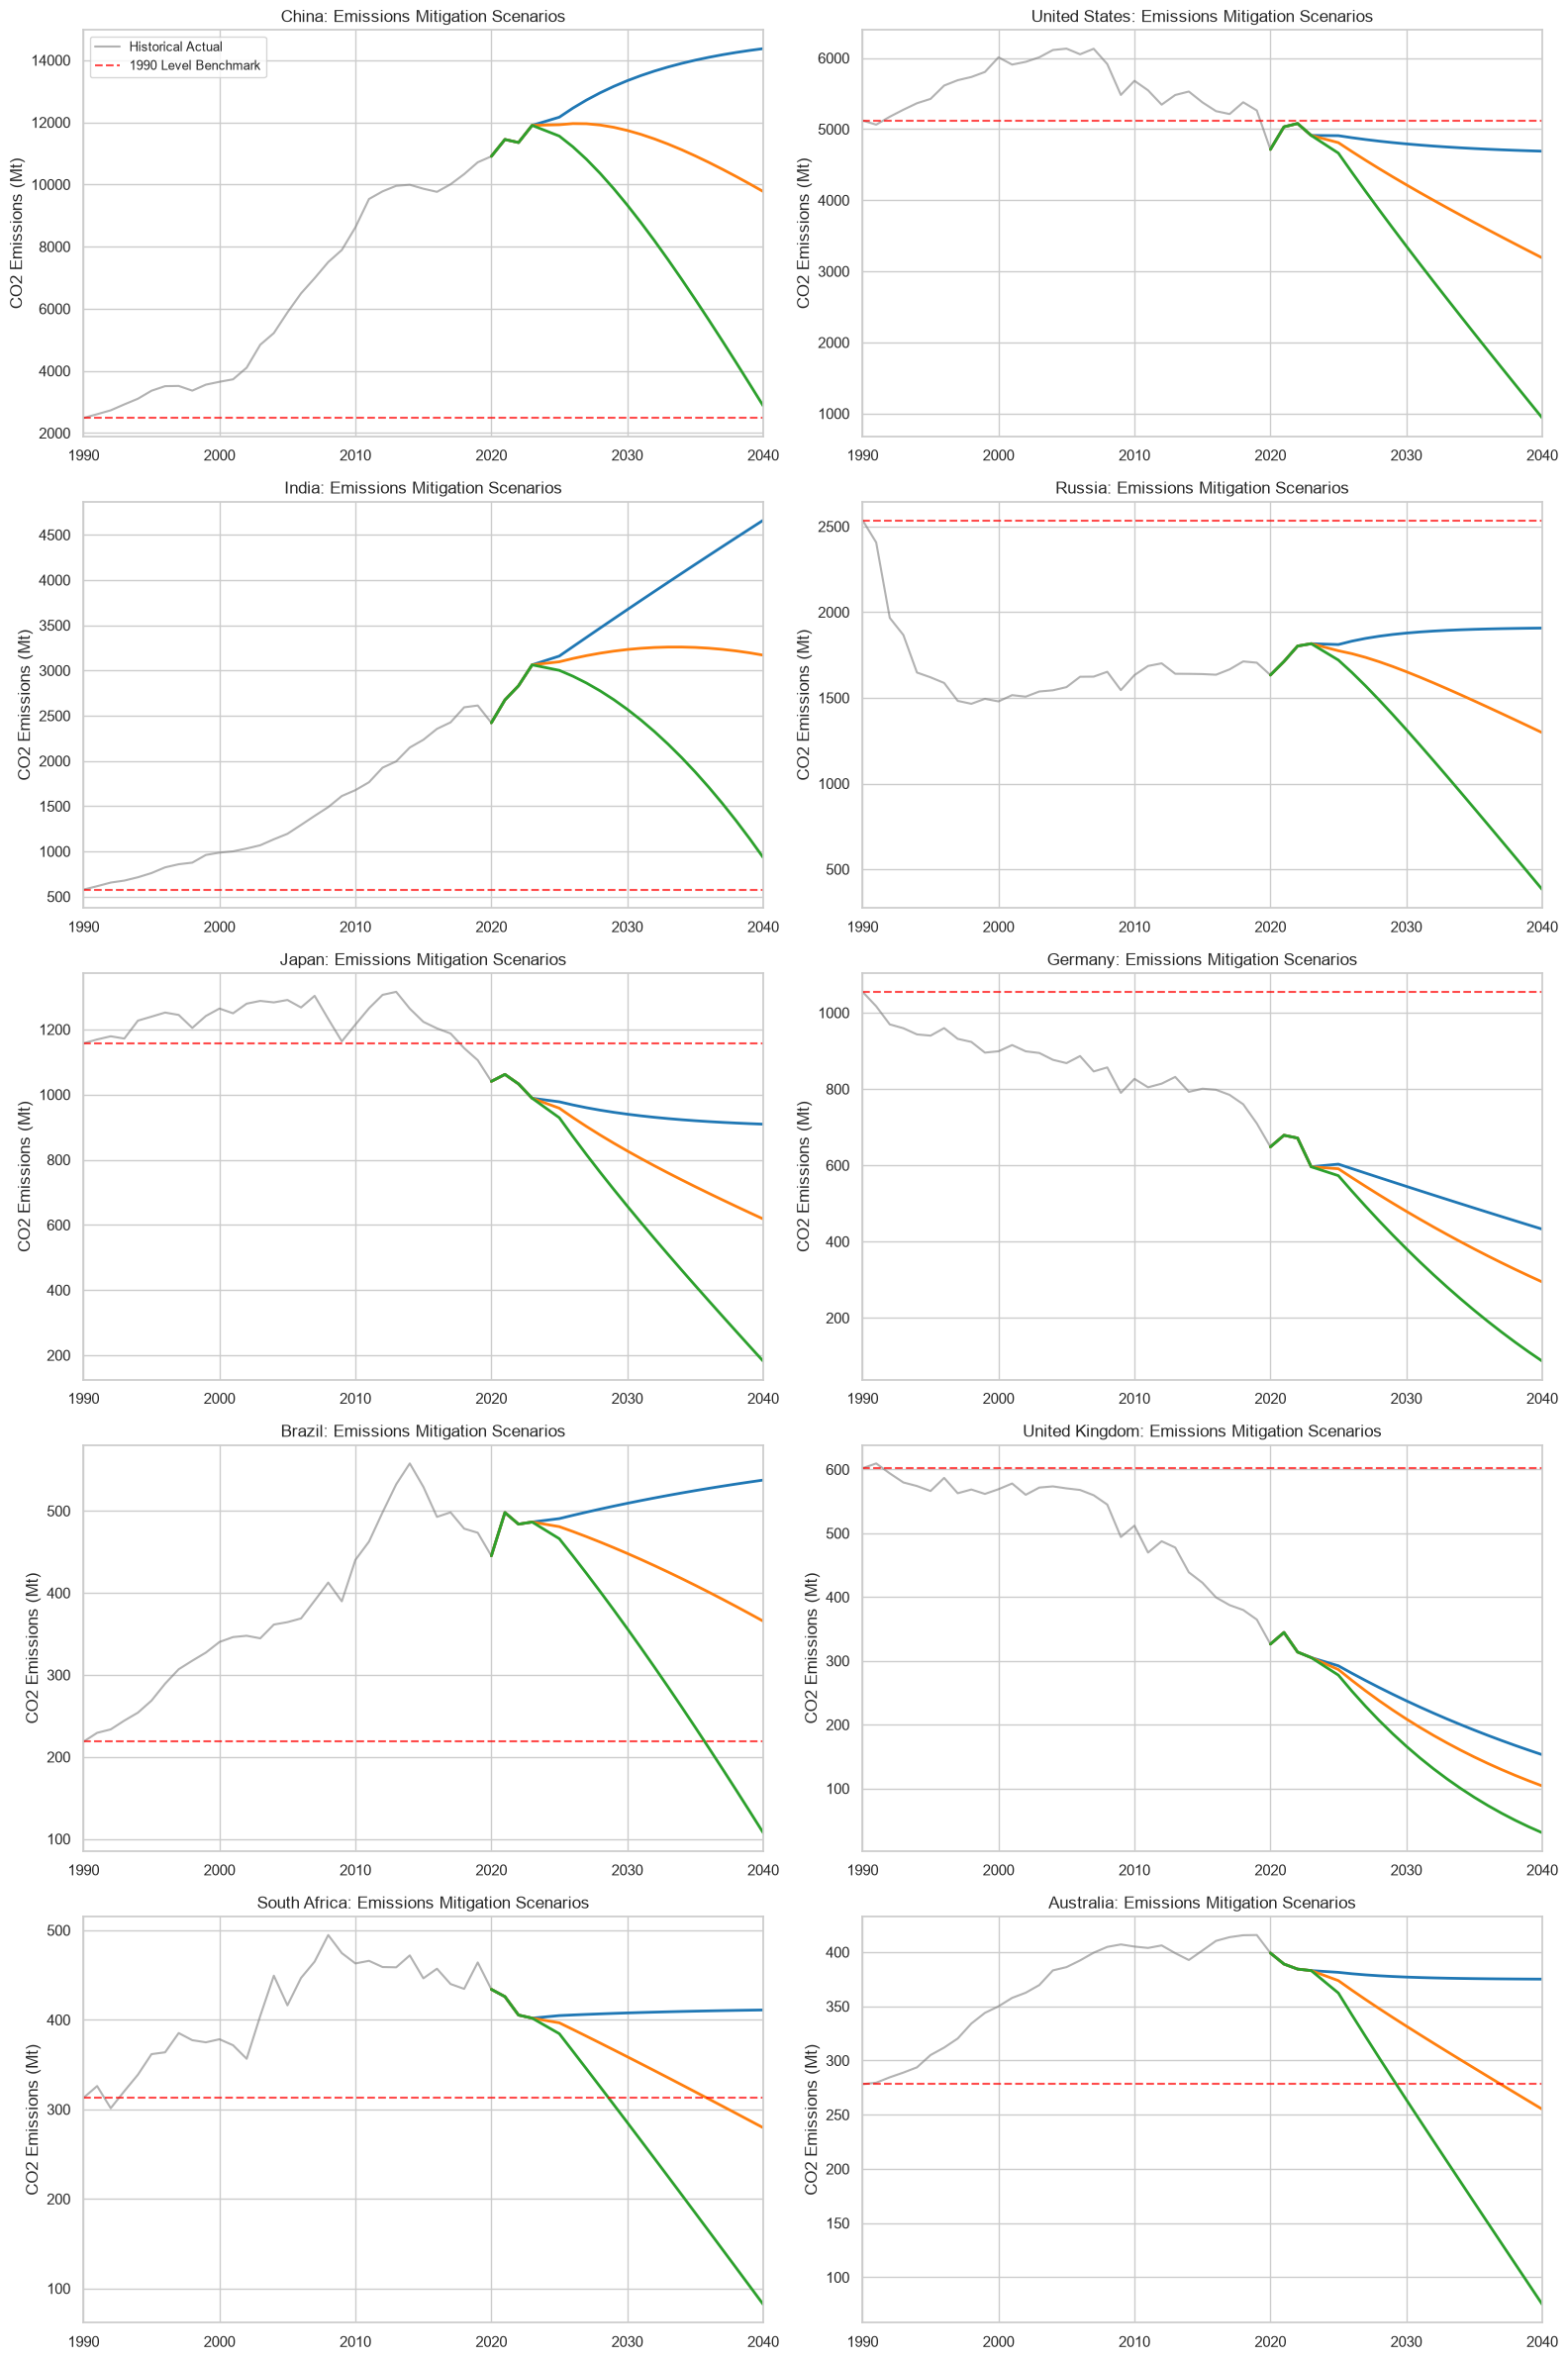

In [3]:
# Create individual line charts for all 10 target countries
fig, axes = plt.subplots(5, 2, figsize=(16, 24), sharex=False)
axes = axes.flatten()

colors = {"BAU": "#1f77b4", "Moderate Mitigation": "#ff7f0e", "Aggressive Mitigation": "#2ca02c"}

for i, country in enumerate(focus_countries):
    ax = axes[i]
    
    # 1. Plot Historical Reference Line (1990 - 2024) in Grey
    hist_subset = df_hist[df_hist["country"] == country]
    ax.plot(hist_subset["year"], hist_subset["co2"], color="#7f7f7f", linestyle="-", alpha=0.6, label="Historical Actual")
    
    # 2. Extract and Plot Individual Scenarios (2020-2040)
    # Include historical context from 2020 to link smoothly
    context_2020_2024 = hist_subset[hist_subset["year"] >= 2020][["year", "co2"]]
    
    scen_subset = df_scenarios[df_scenarios["country"] == country]
    
    for scen_name, color in colors.items():
        scen_data = scen_subset[scen_subset["scenario"] == scen_name]
        
        # Glue historical 2020-2024 tail to projection for continuous visualization lines
        connect_x = list(context_2020_2024["year"]) + list(scen_data["year"])
        connect_y = list(context_2020_2024["co2"]) + list(scen_data["co2_projected"])
        
        ax.plot(connect_x, connect_y, color=color, linewidth=2, label=scen_name if year == 2025 else "")

    # 3. Establish 1990 Policy Benchmark Line
    co2_1990 = hist_subset[hist_subset["year"] == 1990]["co2"]
    if not co2_1990.empty:
        ax.axhline(y=co2_1990.values[0], color="red", linestyle="--", alpha=0.7, label="1990 Level Benchmark")
        
    ax.set_title(f"{country}: Emissions Mitigation Scenarios")
    ax.set_ylabel("CO2 Emissions (Mt)")
    ax.set_xlim(1990, 2040)
    if i == 0:
        ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

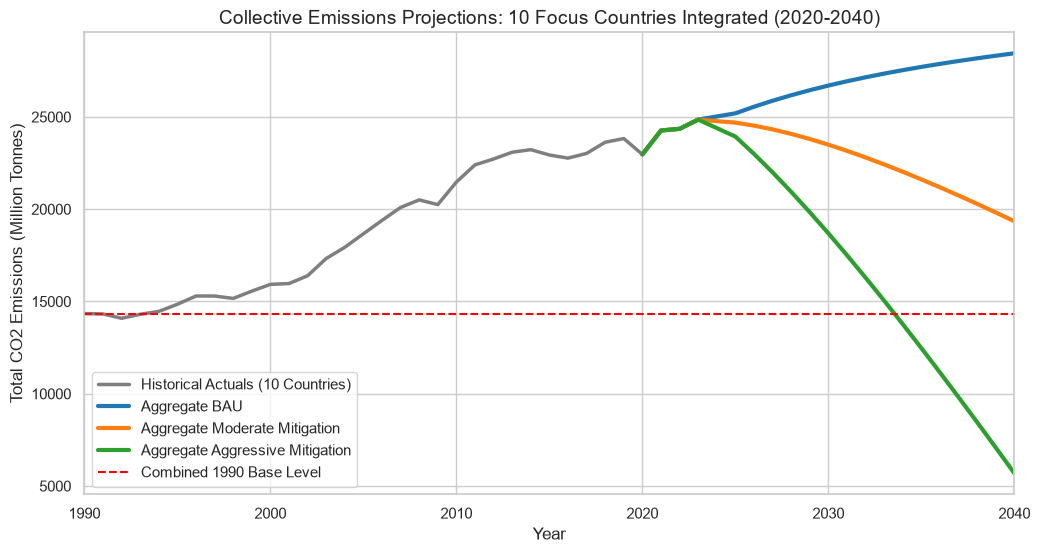

In [4]:
# Calculate collective aggregate trajectories across all 10 countries
hist_global = df_hist.groupby("year")["co2"].sum().reset_index()
scen_global = df_scenarios.groupby(["year", "scenario"])["co2_projected"].sum().reset_index()

plt.figure(figsize=(12, 6))

# Plot Collective Historical Progress
plt.plot(hist_global["year"], hist_global["co2"], color="#7f7f7f", linewidth=2.5, label="Historical Actuals (10 Countries)")

# Link and Plot Collective Aggregates
hist_tail = hist_global[hist_global["year"] >= 2020]
for scen_name, color in colors.items():
    scen_data = scen_global[scen_global["scenario"] == scen_name]
    
    agg_x = list(hist_tail["year"]) + list(scen_data["year"])
    agg_y = list(hist_tail["co2"]) + list(scen_data["co2_projected"])
    
    plt.plot(agg_x, agg_y, color=color, linewidth=3, label=f"Aggregate {scen_name}")

# Total 1990 Aggregate Benchmark
global_1990 = hist_global[hist_global["year"] == 1990]["co2"].values[0]
plt.axhline(y=global_1990, color="red", linestyle="--", linewidth=1.5, label="Combined 1990 Base Level")

plt.title("Collective Emissions Projections: 10 Focus Countries Integrated (2020-2040)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total CO2 Emissions (Million Tonnes)", fontsize=12)
plt.xlim(1990, 2040)
plt.legend(loc="lower left")
plt.show()

### 5.4 Cumulative Policy Impact Analysis

Evaluating absolute annual points does not account for total atmospheric accumulation. To measure environmental efficacy, we calculate **total cumulative $CO_2$ mass saved** between **2025 and 2040**.

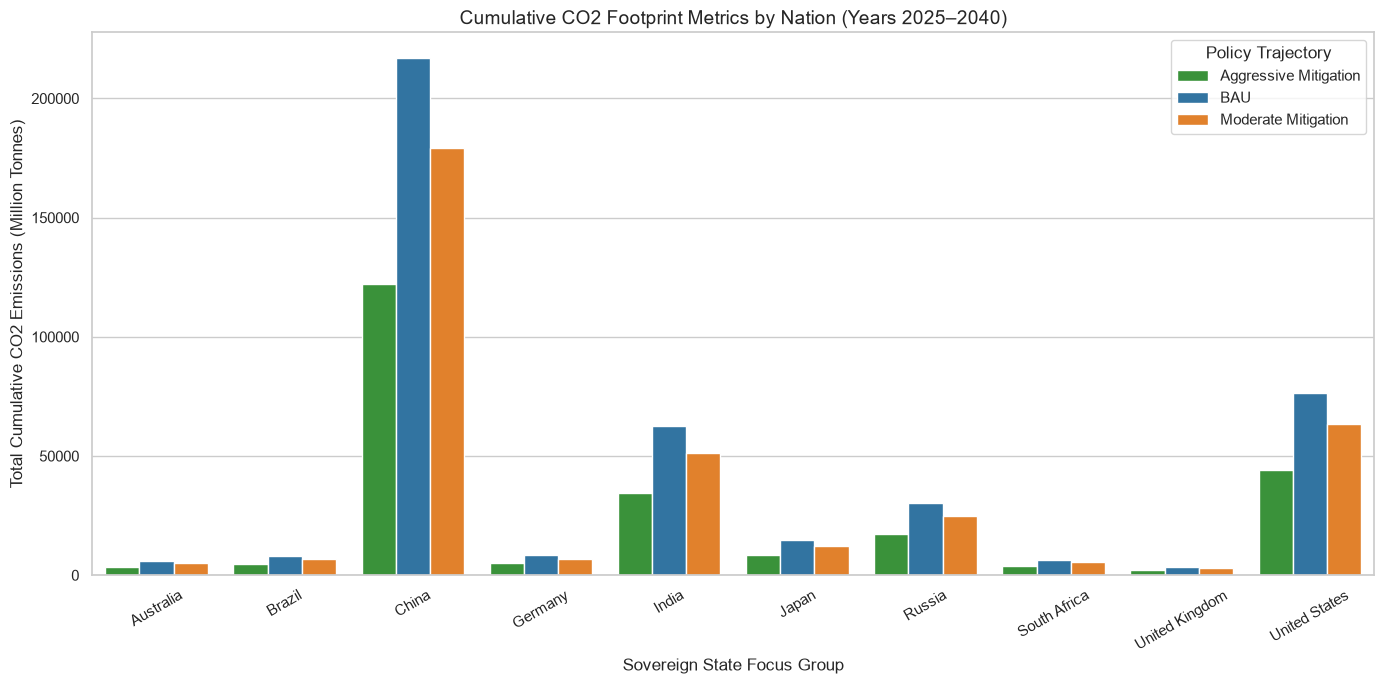

In [5]:
# Calculate cumulative emissions over the implementation horizon (2025-2040)
cumulative_data = df_scenarios.groupby(["country", "scenario"])["co2_projected"].sum().reset_index()
cumulative_data.rename(columns={"co2_projected": "cumulative_co2"}, inplace=True)

# Generate Grouped Bar Chart
plt.figure(figsize=(14, 7))
sns.barplot(
    data=cumulative_data, 
    x="country", 
    y="cumulative_co2", 
    hue="scenario", 
    palette={"BAU": "#1f77b4", "Moderate Mitigation": "#ff7f0e", "Aggressive Mitigation": "#2ca02c"}
)

plt.title("Cumulative CO2 Footprint Metrics by Nation (Years 2025–2040)", fontsize=14)
plt.xlabel("Sovereign State Focus Group", fontsize=12)
plt.ylabel("Total Cumulative CO2 Emissions (Million Tonnes)", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="Policy Trajectory")
plt.tight_layout()
plt.show()

### 5.5 Analytical Synthesis & Major Observations

* **Mitigation Returns:** Developing economies with expanding industrial baselines under **Business As Usual** setups (such as China and India) demonstrate the largest absolute savings when moving to an **Aggressive Mitigation** framework.
* **Target Benchmarking:** Developed post-peak emitters (such as the UK and Germany) can hold their paths comfortably below their **1990 Baseline Marks** using a Moderate framework. High volume emitters require an Aggressive framework to approach their historical baselines.
* **Structural Limitations:** Because mitigation models use constant fixed percentages, the calculations ignore localized infrastructure limits. This serves as a structural reminder that real-world deployment requires custom, sector-specific scaling rules.